## Anthopic Model

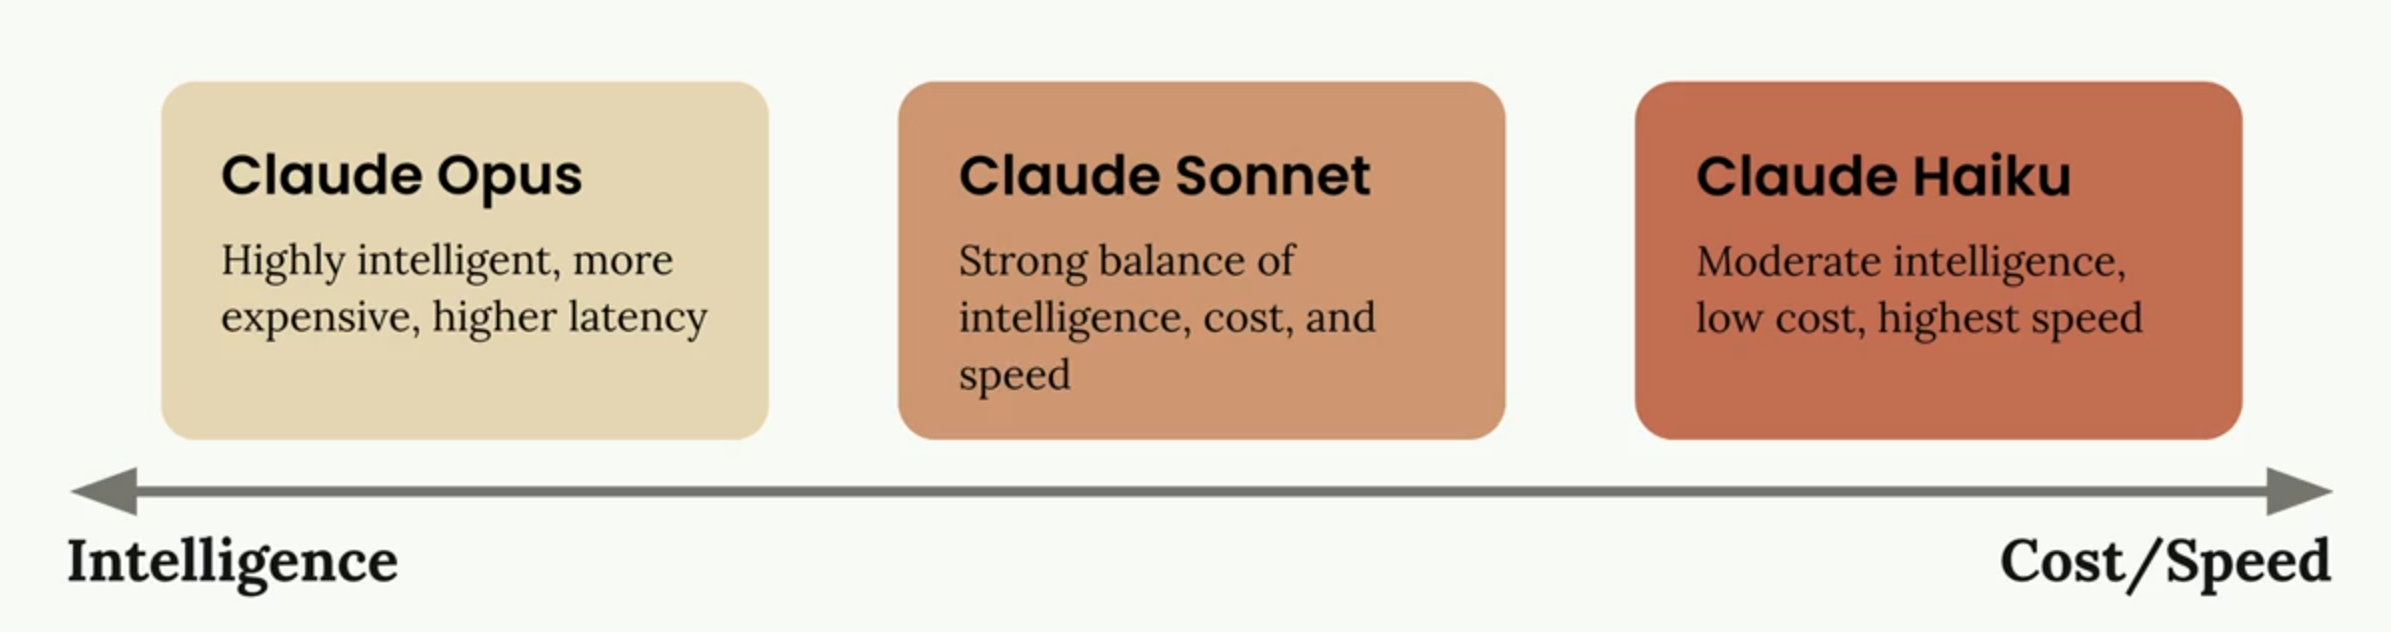

## Accessing API

### The Five-Step Request Flow(from prompt to response)

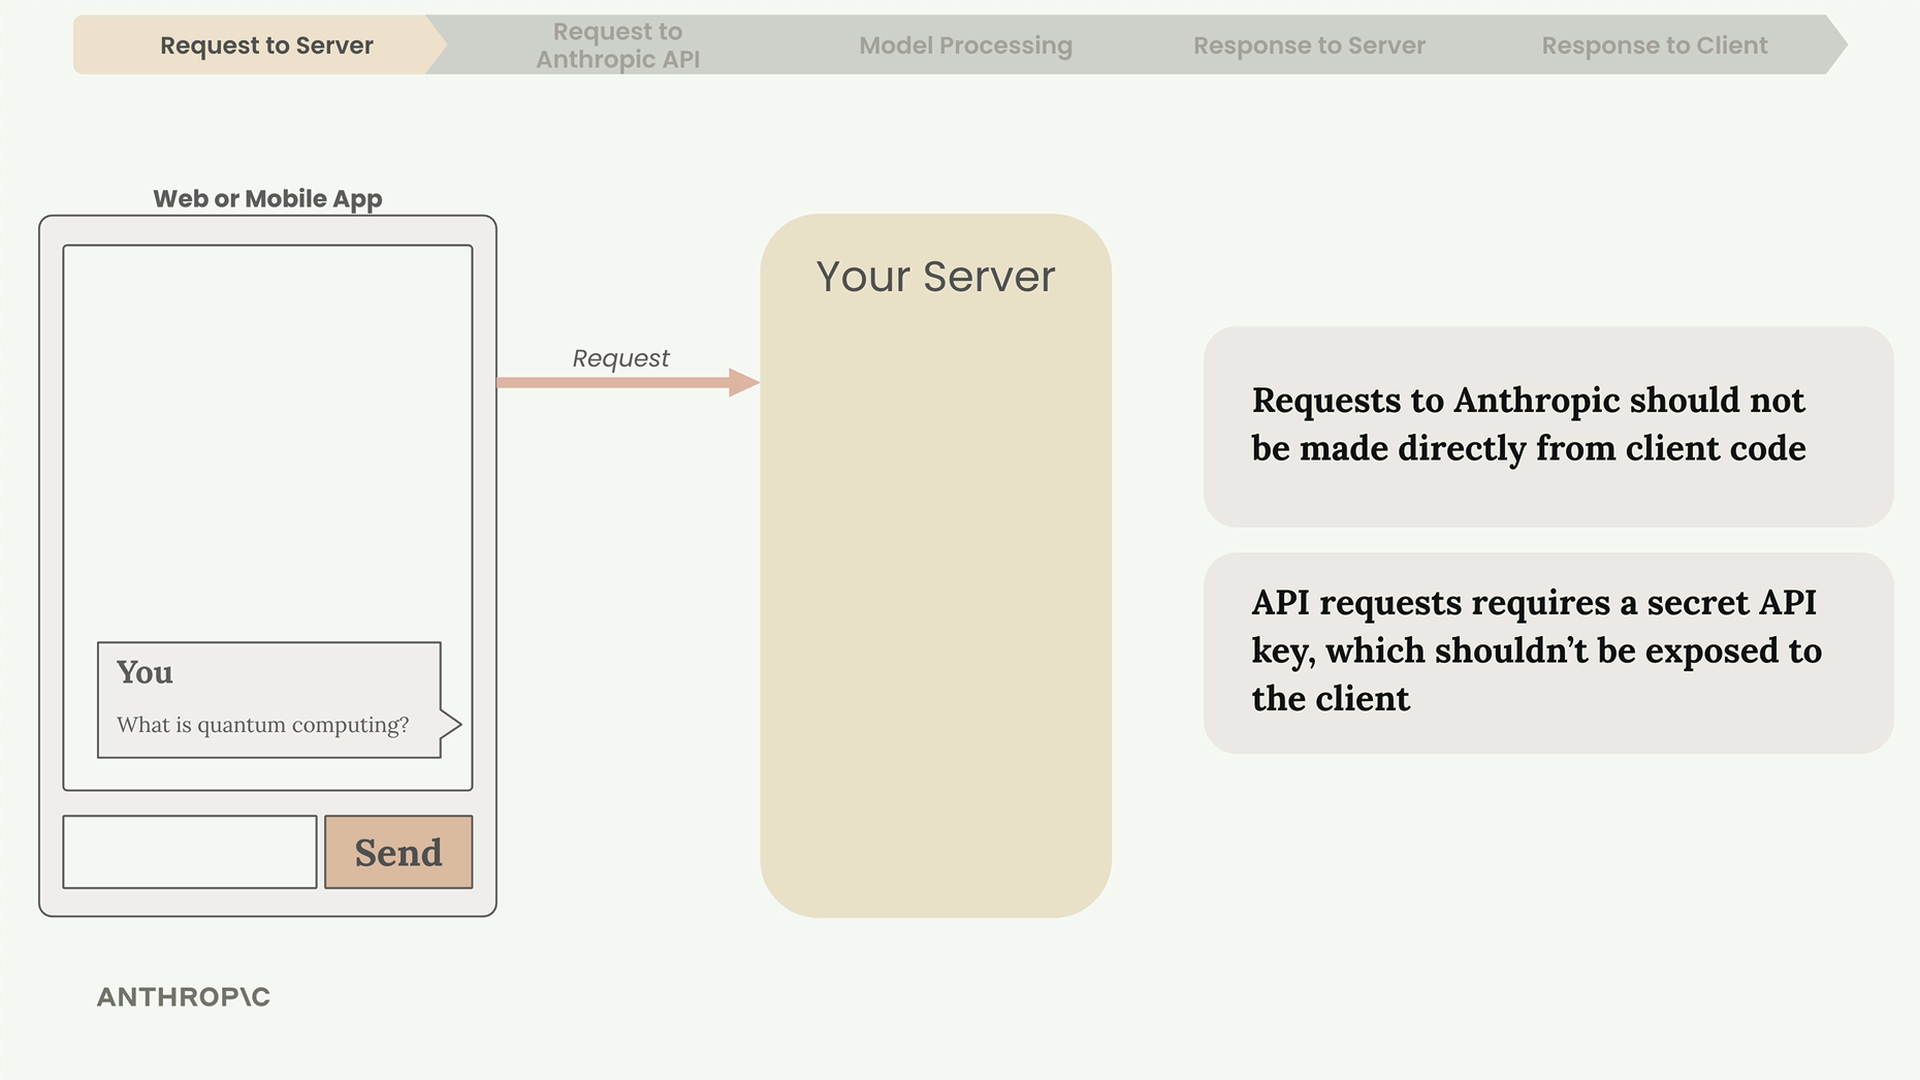

#### 1. Request to Server



    Requests to Anthropic should not be made directly from client code.
    API requests requires a secret API Key, which shouldn't be exposed to the client. 




```
            User's Browser                Your Server              Anthropic API
            ─────────────                 ───────────              ────────────
            "Summarize this text"  ──▶   receives request   ──▶   POST /v1/messages
                                        attaches API key          (with secret key)
            "Here's the summary"  ◀──   forwards response  ◀──   returns result
```

#### 2. Accessing the API

Requests to the API can be made through SDK or just Plain HTTP request.


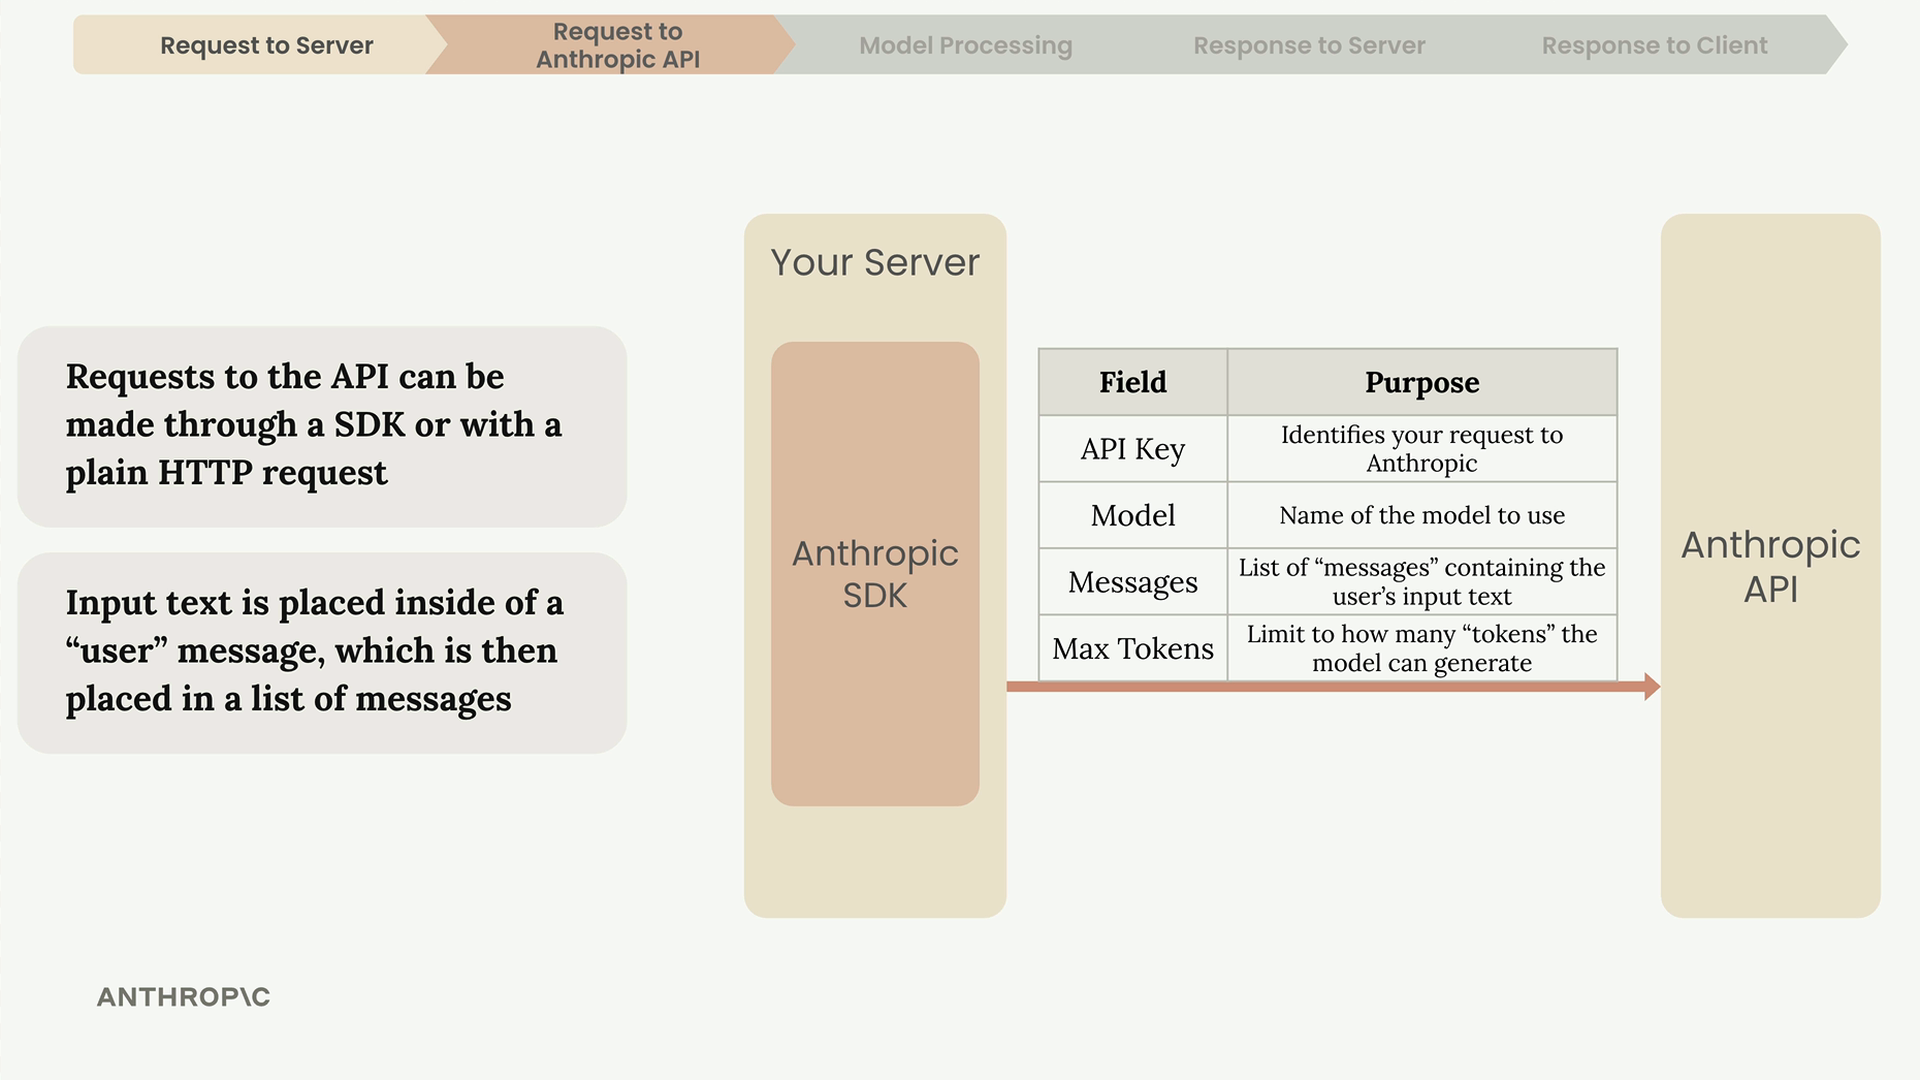

### 3. Model Processing (within Anthropic)

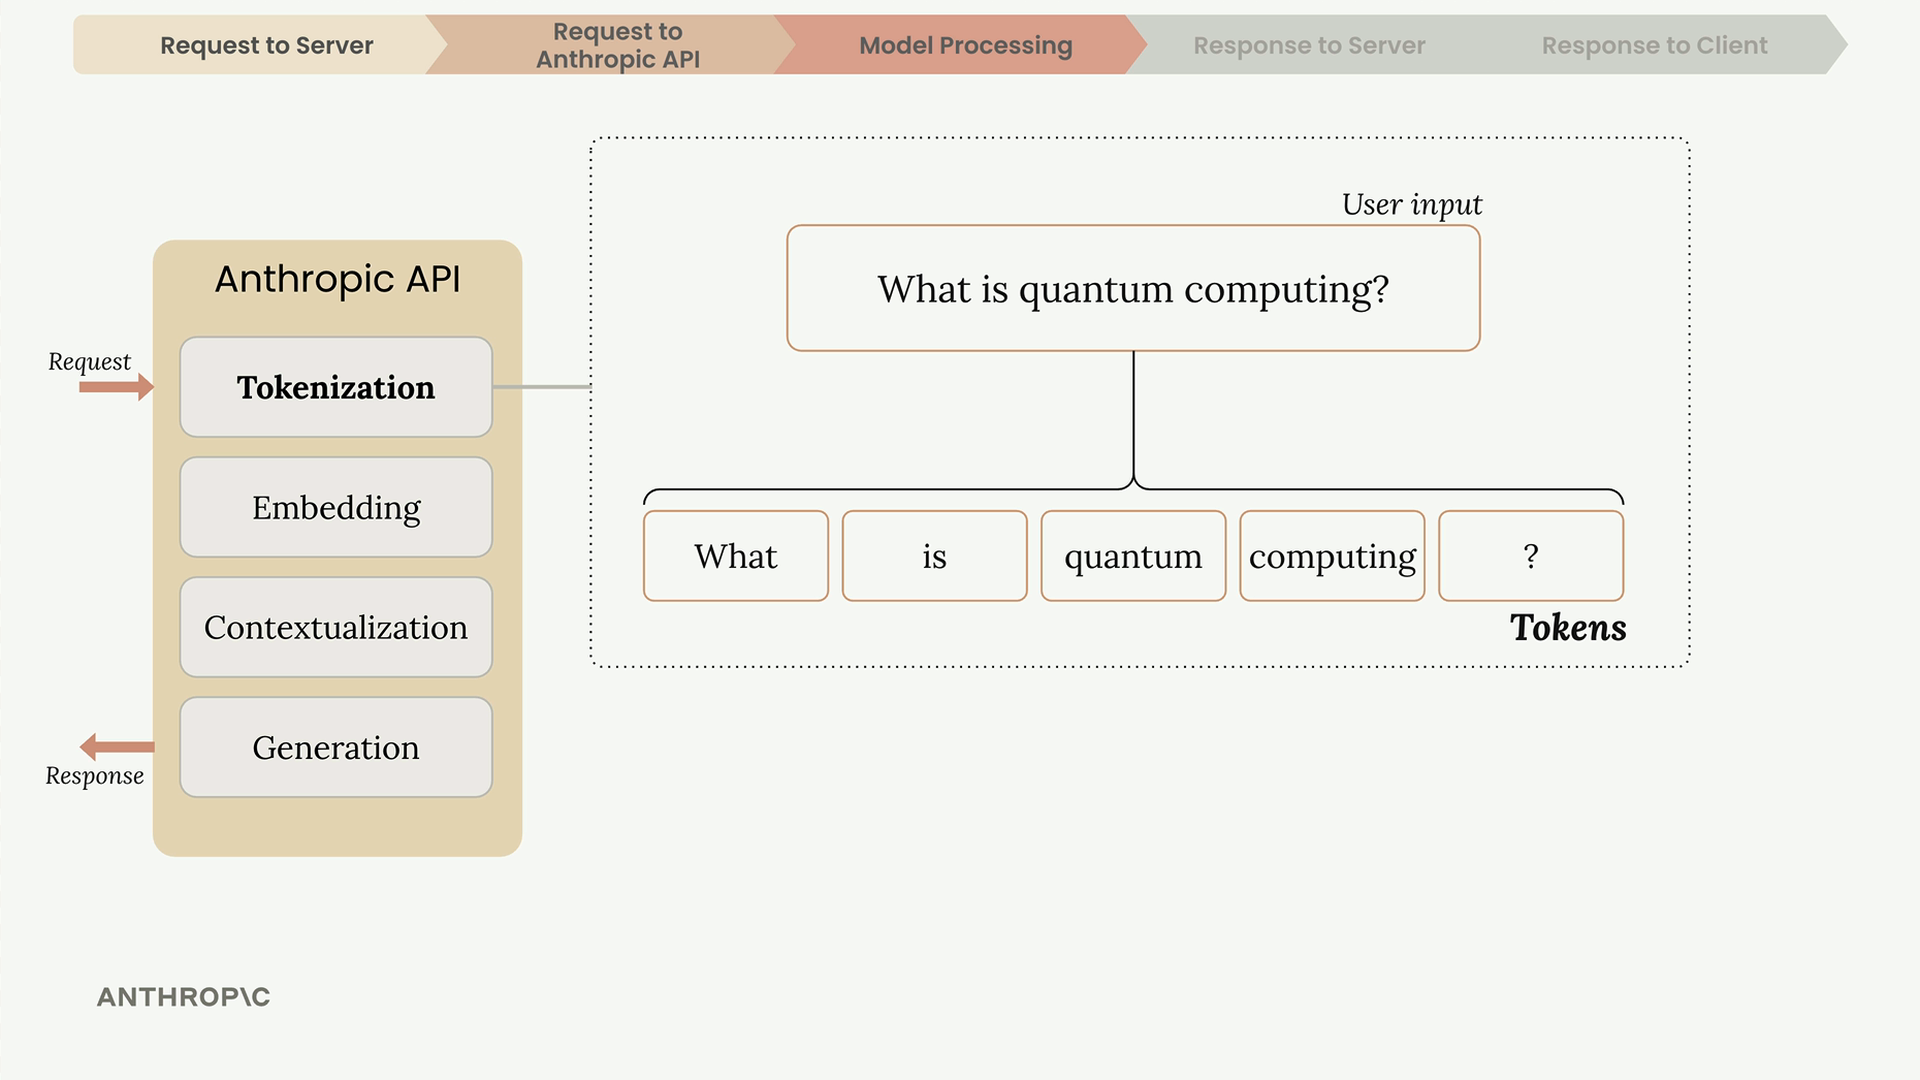

1. Tokenization
    Claude first breaks your input text into smaller chunks called tokens. These can be whole words, parts of words, spaces, or symbols. For simplicity, think of each word as one token.
2. Embedding 
    Numerical Definitions to capture semantic relationships
3. Contextualization
    Refines embedding based on surrounding works(context)

4. Generation
    Generate next words

5. After each token, Claude checks for conditions to stop
    Max Tokens
    Natural ending(eos)
    Stop Sequence




#### 4. The API response


    
the API sends back a structured response containing:

        Message - The generated text
        Usage - Count of input and output tokens
        Stop Reason - Why generation ended

#### Server Response

Your server receives this response and forwards the generated text back to your client application, where it appears in the user interface.

## Making a request

In [ ]:
# Install Dependencies:
%pip install anthropic python-dotenv
# dotenv is used to load environment variables from a .env file, which is a common practice for managing API keys and other sensitive information in development environments.

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Load env variables

from dotenv import load_dotenv
load_dotenv()

True

In [13]:
# Create an API client
from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-0"


In [ ]:
# Make a request to the API
# The core of making API requests is the `client.messages.create()` method. 


message = client.messages.create(
    model=model,
    max_tokens=1024,
    messages=[
        {"role": "user", 
         "content": "What is quantum compunting? answer in one sentece"}]
)

In [ ]:
# the response from the API is stored in the `message` variable, 
# and you can access the content of the response using `message.content[0].text`.

message
print(message.content[0].text)

### Multi-Turn Conversations


What we did above just create a one-shot request. 
The Anthropic API and Claude do not store any messages. To have a "conversation(flow)" you need to: 

1. Manually maintain a list of messages in the code
2. Provide that list of messages with each follow up request

In [21]:
# helpper function
def add_user_message(messages,text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)
    return messages
def add_assistant_message(messages,text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)
    return messages

def chat(messages):
    response = client.messages.create(
        model=model,
        max_tokens=1024,
        messages=messages
    )
    return response




In [25]:
# Make a starting list of messages
messages = []

# Add a user message to the list
add_user_message(messages, "What is quantum computing? answer in one sentence")
answer = chat(messages)
print(answer.content[0].text)

Quantum computing is a revolutionary computing paradigm that uses quantum mechanical phenomena like superposition and entanglement to process information in ways that can potentially solve certain problems exponentially faster than classical computers.


In [26]:
add_assistant_message(messages, answer.content[0].text)
messages

[{'role': 'user',
  'content': 'What is quantum computing? answer in one sentence'},
 {'role': 'assistant',
  'content': 'Quantum computing is a revolutionary computing paradigm that uses quantum mechanical phenomena like superposition and entanglement to process information in ways that can potentially solve certain problems exponentially faster than classical computers.'}]

In [27]:
add_user_message(messages, "What is the difference between quantum computing and classical computing? answer in one sentence")

answer = chat(messages)
print(answer.content[0].text)

The key difference is that classical computing uses bits that exist in definite states of 0 or 1, while quantum computing uses quantum bits (qubits) that can exist in superposition of both 0 and 1 simultaneously, allowing quantum computers to process multiple possibilities in parallel.


#### Exercise
Using the three helper function and use the `input` function to prompt user to enter message

In [30]:
messages = []
while True:
    user_input = input("User: ")
    print("User:", user_input)
    add_user_message(messages, user_input)
    answer = chat(messages)
    print("Assistant:", answer.content[0].text)
    add_assistant_message(messages, answer.content[0].text)

User: what is 1+1
Assistant: 1 + 1 = 2
User: +1 more
Assistant: 2 + 1 = 3
User: 


BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.4: user messages must have non-empty content'}, 'request_id': 'req_011CZhSwxHBTzjZTJykedcDf'}

### System Prompts

Customizes Claude's tone and style of response

In [31]:
messages = []
add_user_message(messages, "How do I solve 5x+3=0?")
answer = chat(messages)


In [33]:
# rewrite chat function to include system prompt "system"
def chat(messages):
    response = client.messages.create(
        model=model,
        max_tokens=1024,
        messages=messages,
        system="You are a helpful assistant that answers questions about math problems."
        
        
    )
    return response

In [34]:
add_user_message(messages, "How do I solve 5x+3=0?")
answer = chat(messages)

In [35]:
print(answer.content[0].text)

To solve the equation 5x + 3 = 0, you need to isolate x. Here's how to do it step by step:

**Step 1:** Subtract 3 from both sides
5x + 3 - 3 = 0 - 3
5x = -3

**Step 2:** Divide both sides by 5
5x ÷ 5 = -3 ÷ 5
x = -3/5

**Answer:** x = -3/5 (or x = -0.6 as a decimal)

**Check your work:** Substitute x = -3/5 back into the original equation:
5(-3/5) + 3 = -3 + 3 = 0 ✓

The general strategy for solving linear equations like this is to use inverse operations to isolate the variable on one side of the equation.


#### Building a Flexible Chat function

Rather than hard-coding system propts, you can make the chat function more resuable by accepting system prompts as parameters


In [ ]:
system = "You are a helpful assistant that answers questions about math problems."
def chat(messages, system=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
    }
    
    if system:
        params["system"] = system
    
    message = client.messages.create(**params)
    return message.content[0].text

answer = chat(messages, system="system")
print(answer)

To solve 5x + 3 = 0, I need to isolate x by getting it alone on one side of the equation.

Here are the steps:

**Step 1:** Subtract 3 from both sides
5x + 3 - 3 = 0 - 3
5x = -3

**Step 2:** Divide both sides by 5
5x ÷ 5 = -3 ÷ 5
x = -3/5

**Answer:** x = -3/5 (or -0.6 as a decimal)

**Check:** Let me verify this is correct by substituting back into the original equation:
5(-3/5) + 3 = -15/5 + 3 = -3 + 3 = 0 ✓

The solution is x = -3/5.


### Temperture

Temperature is a powerful parameter that controls how predictable or creative Claude's responses will be. Understanding how to use it effectively can dramatically improve your AI applications.

At low temperatures (near 0), Claude becomes very deterministic - it almost always picks the highest probability token. At high temperatures (near 1), Claude distributes probability more evenly across options, leading to more varied and creative outputs.



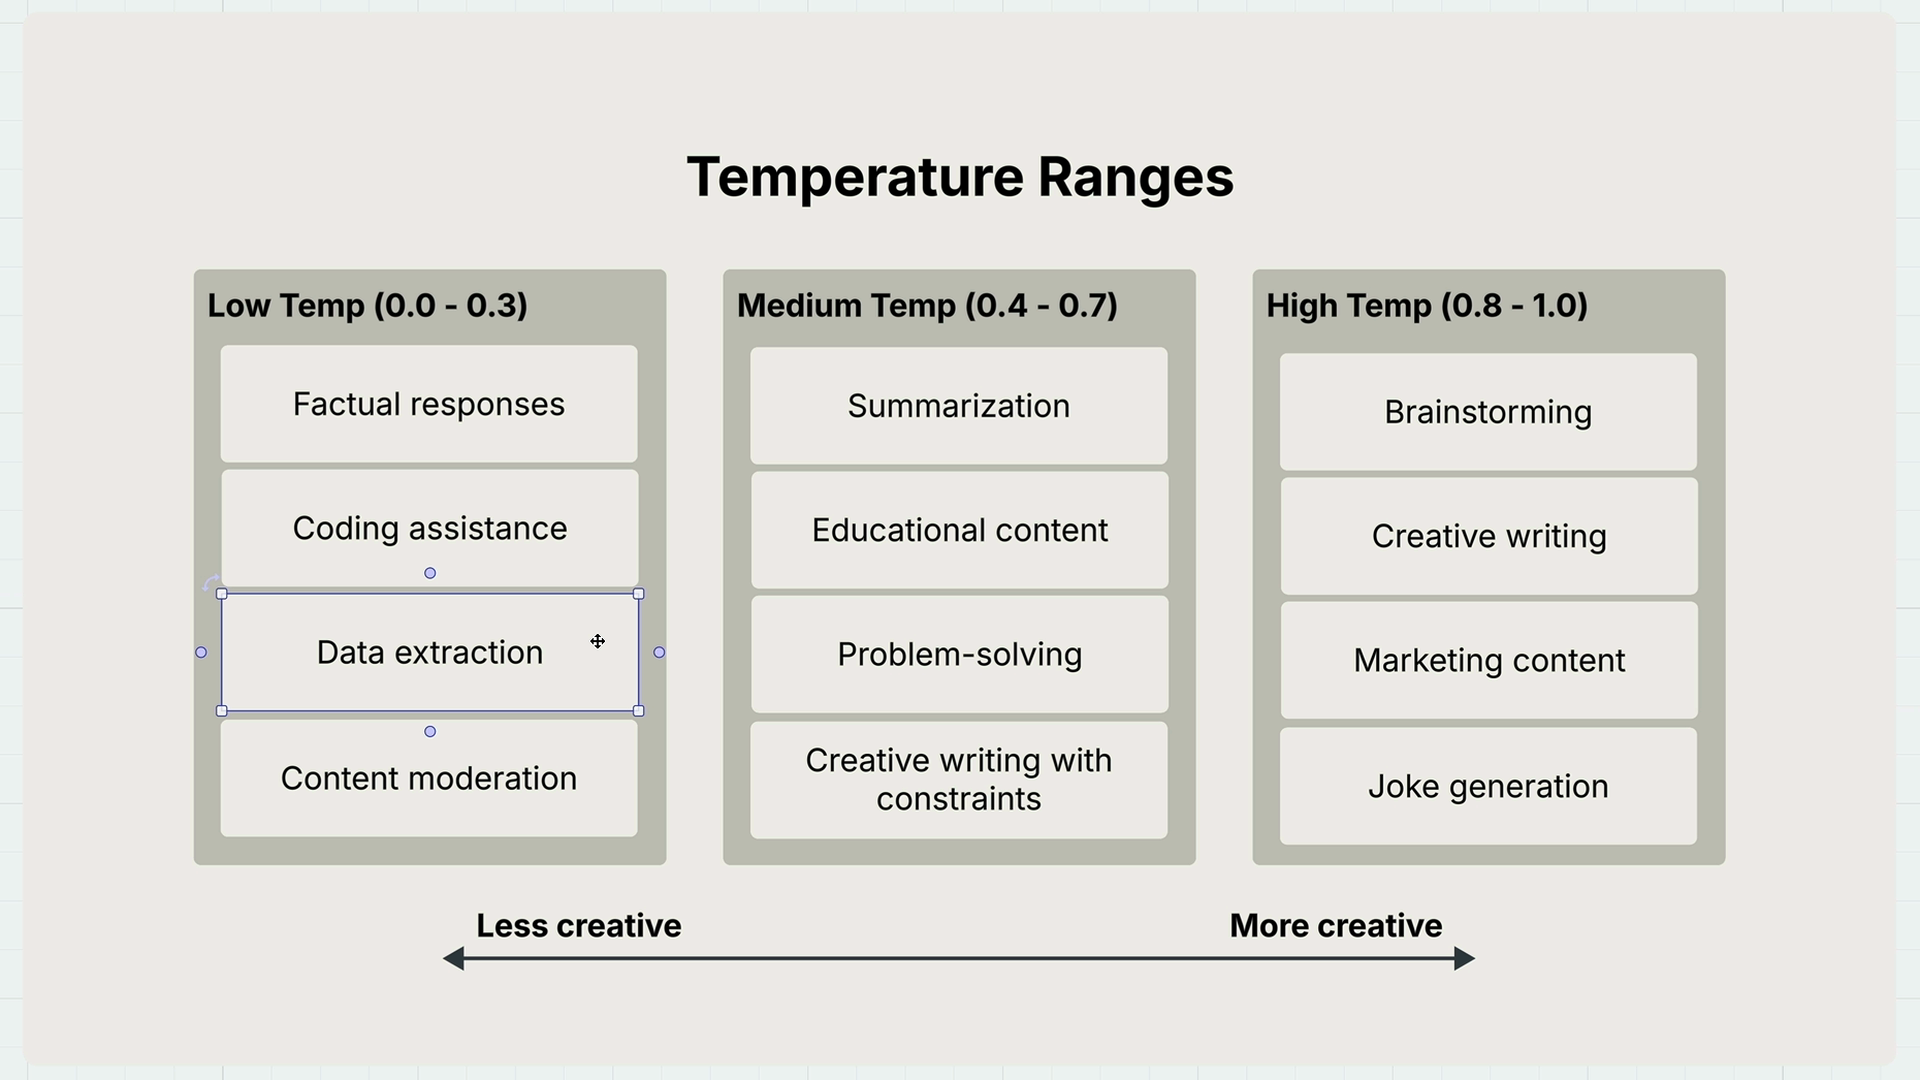

In [46]:
# adding temperture 
def chat(messages, system=None, temperature=1.0,stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }

    if stop_sequences:
        params["stop_sequences"] = stop_sequences
    
    
    if system:
        params["system"] = system
    
    message = client.messages.create(**params)
    return message.content[0].text

In [41]:

# Low temperature - more predictable
answer = chat(messages, temperature=0.0)
print(f"temp=0.0: {answer}")

# High temperature - more creative  
answer = chat(messages, temperature=1.0)
print(f"temp=1.0: {answer}")

temp=0.0: To solve 5x + 3 = 0, you need to isolate x by getting it alone on one side of the equation.

Here are the steps:

**Step 1:** Subtract 3 from both sides
5x + 3 - 3 = 0 - 3
5x = -3

**Step 2:** Divide both sides by 5
5x ÷ 5 = -3 ÷ 5
x = -3/5

**Answer:** x = -3/5 (or x = -0.6 as a decimal)

**Check your answer:** Substitute x = -3/5 back into the original equation:
5(-3/5) + 3 = -3 + 3 = 0 ✓
temp=1.0: To solve 5x + 3 = 0, you need to isolate x by getting it alone on one side of the equation.

Here are the steps:

**Step 1:** Subtract 3 from both sides
5x + 3 - 3 = 0 - 3
5x = -3

**Step 2:** Divide both sides by 5
5x ÷ 5 = -3 ÷ 5
x = -3/5

**Answer:** x = -3/5 (or x = -0.6 as a decimal)

**Check your work:** Substitute x = -3/5 back into the original equation:
5(-3/5) + 3 = -3 + 3 = 0 ✓


### Response Streaming

Problem with Standard Response: 

A delay where users have no feedback when waiting for the complete response. 

When Streaming is enabled, Claude sends back the servral types of events. 

1. MessageStart - A new message is being sent
2. ContentBlockStart - Start of a new block containing text, tool use, or other content
3. ContentBlockDelta - Chunks of the actual generated text
4. ContentBlockStop - The current content block has been completed
5. MessageDelta - The current message is complete
6. MessageStop - End of information about the current message


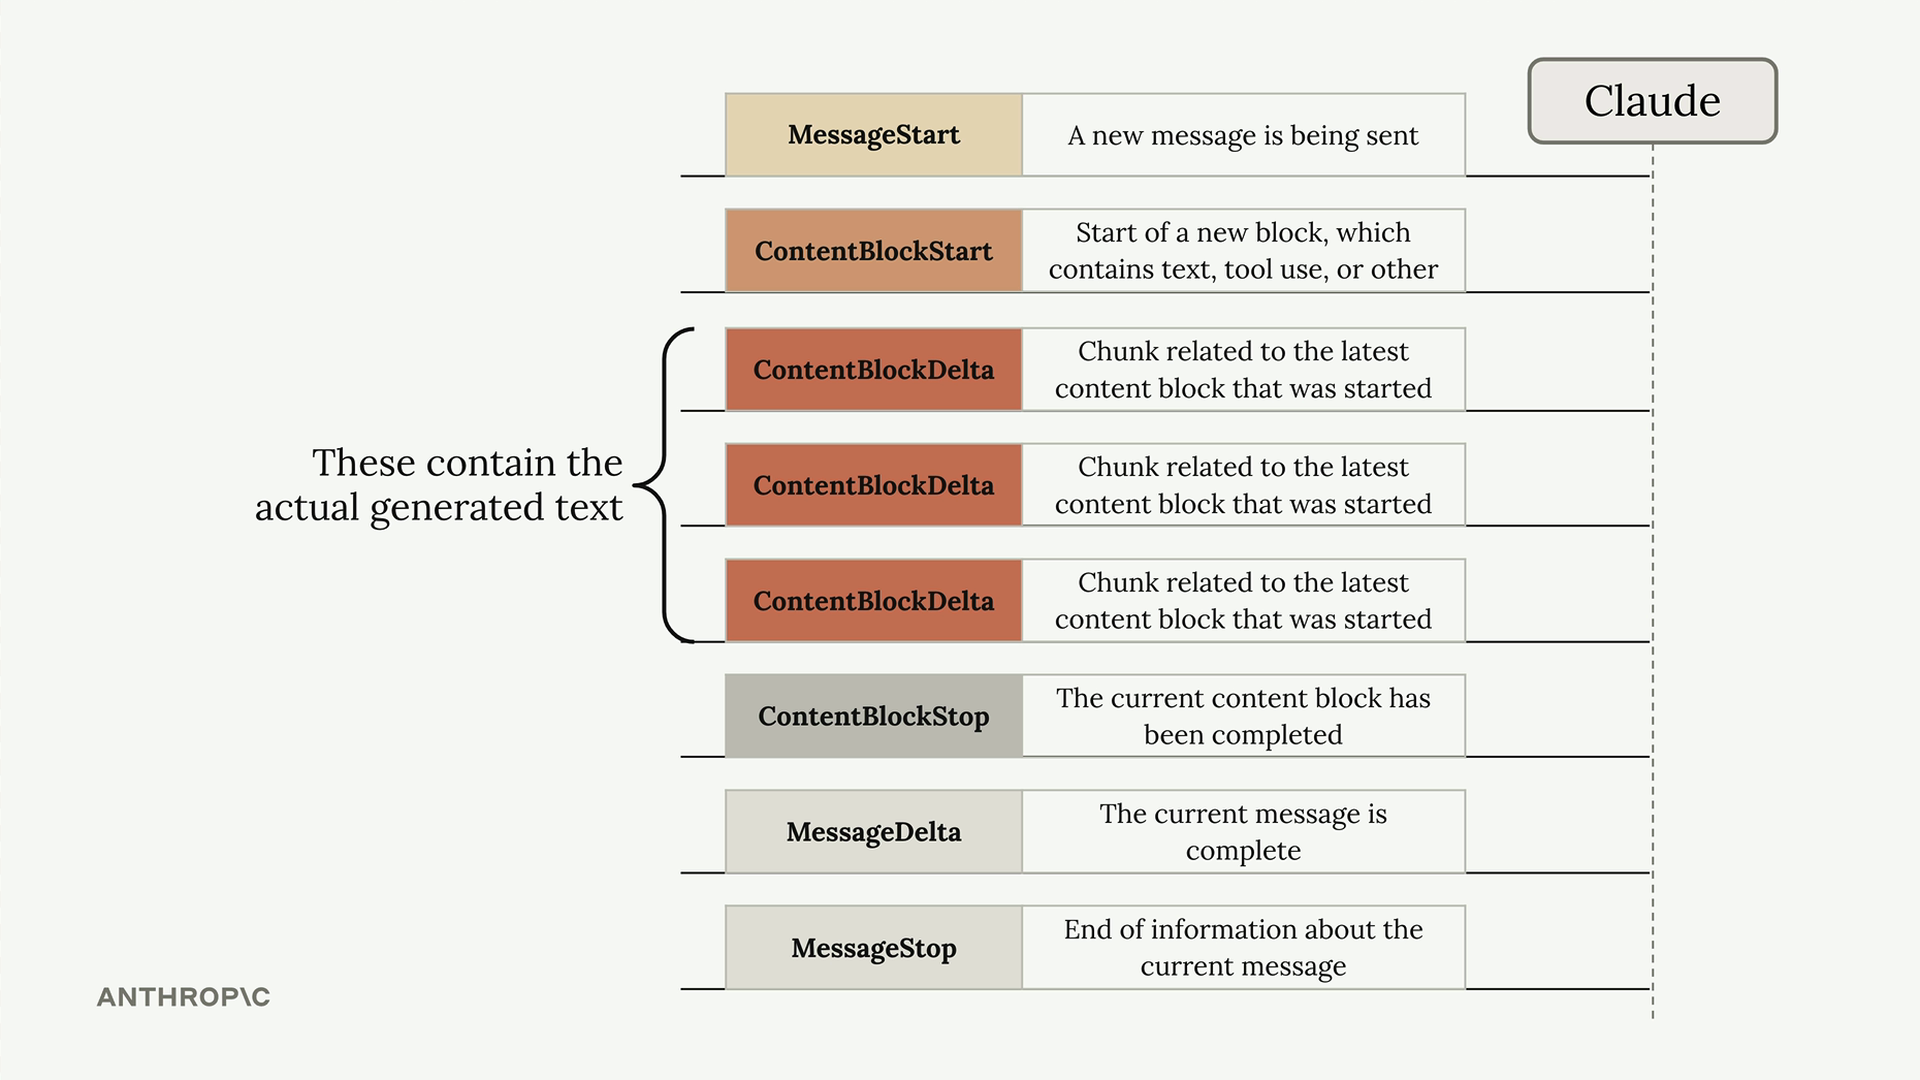

Basic Streaming Implementation

In [42]:
messages = []
add_user_message(messages, "Write a 1 sentence description of a fake database")
stream = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    stream=True # this enables streaming responses from the API
)

for event in stream:
    print(event) # each event contains a chunk of the response as it is generated by the model

RawMessageStartEvent(message=Message(id='msg_014pzpDaAX2trJiTygi5rmQ5', container=None, content=[], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason=None, stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=1, server_tool_use=None, service_tier='standard')), type='message_start')
RawContentBlockStartEvent(content_block=TextBlock(citations=None, text='', type='text'), index=0, type='content_block_start')
RawContentBlockDeltaEvent(delta=TextDelta(text='Customer', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelta(text='Tracker3000 is a comprehensive database system that stores detailed behavioral profiles,', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelta(t

We see the all events have been printed out. But we just want to context。
While streaming individual chunks is great for user experience, you often need the complete message for storage or further processing. After streaming completes, you can get the assembled final message:



In [44]:
with client.messages.stream(        # opens a streaming connection to Claude
    model=model,                    # which Claude model to use
    max_tokens=1000,                # max tokens in the response
    messages=messages               # the conversation history
) as stream:                        # binds the stream to variable 'stream', auto-closes when done
    for text in stream.text_stream: # iterates over response chunks as they arrive in real-time
        print(text)                   # prints each chunk of text as it is received from the API
        #pass                        # placeholder — replace with your logic (e.g. print(text))
    
    final_message = stream.get_final_message()  # returns the complete assembled message object after streaming finishes


F
akeStoreDB is a simulated e-commerce database containing randomly generated product listings, customer profiles, and transaction records used
 for testing and development purposes without exposing real business data.


- `with` ensures the connection is properly closed 
- `stream` is in replace of the the `create()` function, where it returns text chunk by chunk. 


### Structured Data


When you need Claude to generate structured data like JSON, Python code, or bulleted lists, you'll often run into a common problem: Claude wants to be helpful and add explanatory text around your content.

By default, when you ask Claude to generate JSON, you might get something like this:

```json
{
  "source": ["aws.ec2"],
  "detail-type": ["EC2 Instance State-change Notification"],
  "detail": {
    "state": ["running"]
  }
}
```

This rule captures EC2 instance state changes when instances start running.

this is correct, it's just that the code is wraped with text and can not be directly used. 

#### Solution

**Assistant Message Prefilling + Stop Sequences**
You can combine assistant message prefilling with stop sequences to get exactly the content you want. Here's how it works:

In [47]:
messages = []

add_user_message(messages, "Generate a very short event bridge rule as json")
add_assistant_message(messages, "```json")


text = chat(messages, stop_sequences=["```"]) # API stops generating test when it sees "```""

In [52]:
print(text) #
import json

# Clean up and parse the JSON
clean_json = json.loads(text.strip())
print("\n --------------------")
print(clean_json)


{
  "Name": "OrderProcessingRule",
  "EventPattern": {
    "source": ["myapp.orders"],
    "detail-type": ["Order Placed"]
  },
  "Targets": [
    {
      "Id": "1",
      "Arn": "arn:aws:lambda:us-east-1:123456789012:function:ProcessOrder"
    }
  ]
}


 --------------------
{'Name': 'OrderProcessingRule', 'EventPattern': {'source': ['myapp.orders'], 'detail-type': ['Order Placed']}, 'Targets': [{'Id': '1', 'Arn': 'arn:aws:lambda:us-east-1:123456789012:function:ProcessOrder'}]}
